In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor
from sklearn.datasets import make_blobs

In [2]:
np.random.seed(42)

# Generate synthetic data
X, _ = make_blobs(
    n_samples=300, centers=1, cluster_std=0.5, center_box=(0, 0), random_state=42
)
outliers = np.random.uniform(low=-4, high=4, size=(20, 2))
X = np.vstack([X, outliers])

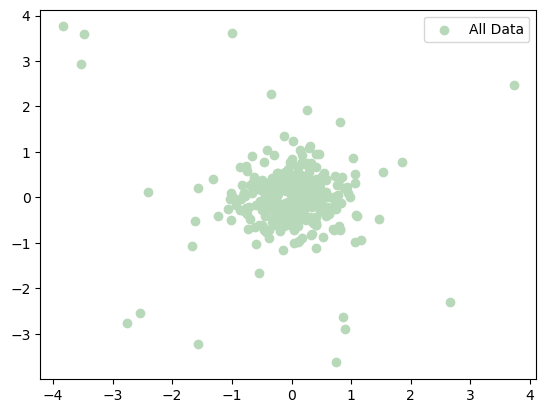

In [3]:
plt.scatter(X[:, 0], X[:, 1], color="#B8D8BA", label="All Data")

plt.legend()
plt.show()

In [4]:
model = LocalOutlierFactor(n_neighbors=20, contamination=0.06)
preds = model.fit_predict(X)
lof_scores = -model.negative_outlier_factor_

inliers = X[preds == 1]
detected_outliers = X[preds == -1]

c:\ProgramData\anaconda3\Lib\site-packages\matplotlib\collections.py:996: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


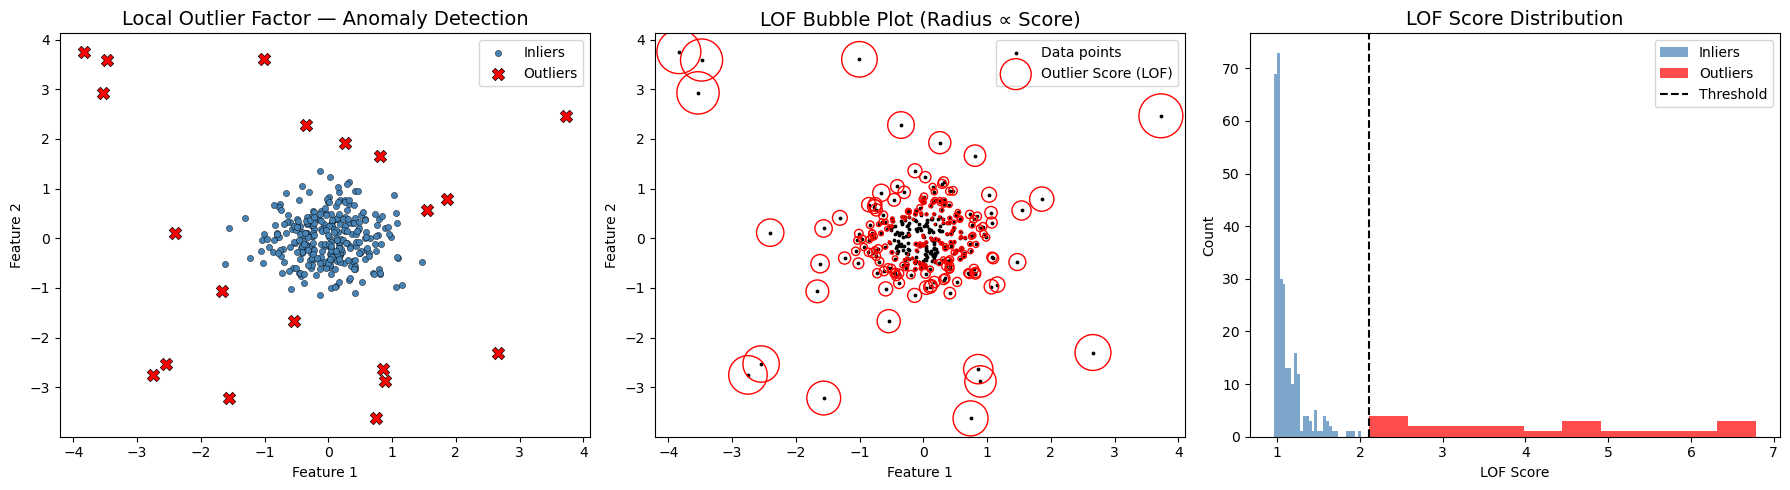

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(
    inliers[:, 0],
    inliers[:, 1],
    c="steelblue",
    s=20,
    edgecolors="k",
    linewidths=0.3,
    label="Inliers",
)
axes[0].scatter(
    detected_outliers[:, 0],
    detected_outliers[:, 1],
    c="red",
    s=80,
    marker="X",
    edgecolors="k",
    linewidths=0.5,
    label="Outliers",
)
axes[0].set_title("Local Outlier Factor — Anomaly Detection", fontsize=14)
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")
axes[0].legend()

axes[1].scatter(X[:, 0], X[:, 1], color="k", s=3, label="Data points")
radius = lof_scores - 1
radius = radius / radius.max()
axes[1].scatter(
    X[:, 0],
    X[:, 1],
    s=1000 * radius,
    edgecolors="r",
    facecolors="none",
    label="Outlier Score (LOF)",
)
axes[1].set_title("LOF Bubble Plot (Radius ∝ Score)", fontsize=14)
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")
axes[1].legend()

axes[2].hist(
    lof_scores[preds == 1], bins=30, alpha=0.7, color="steelblue", label="Inliers"
)
axes[2].hist(lof_scores[preds == -1], bins=10, alpha=0.7, color="red", label="Outliers")
threshold = np.min(lof_scores[preds == -1])
axes[2].axvline(
    x=threshold, color="black", linestyle="--", linewidth=1.5, label="Threshold"
)
axes[2].set_title("LOF Score Distribution", fontsize=14)
axes[2].set_xlabel("LOF Score")
axes[2].set_ylabel("Count")
axes[2].legend()

plt.tight_layout()
plt.show()

In [6]:
print(f"Total samples: {len(X)}")
print(f"Inliers: {len(inliers)}")
print(f"Outliers detected: {len(detected_outliers)}")

Total samples: 320
Inliers: 300
Outliers detected: 20
